In [48]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

# **loading data**

In [49]:
df = pd.read_csv('uber.csv')
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


# **drop useless column**

In [50]:
df = df.drop(columns=['Unnamed: 0','key'],axis=1)

# **handle datetime**

In [51]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1


In [52]:
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['weekend'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year


In [21]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekend,month,year
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19,7,3,5,2015
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20,17,4,7,2009
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21,24,0,8,2009
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8,26,4,6,2009
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17,28,3,8,2014
...,...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,10,28,6,10,2012
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,1,14,4,3,2014
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,0,29,0,6,2009
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,14,20,2,5,2015


In [53]:
df = df.drop(['pickup_datetime'],axis=1)

In [54]:
df

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekend,month,year
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,19,7,3,5,2015
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,20,17,4,7,2009
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,21,24,0,8,2009
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,8,26,4,6,2009
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,17,28,3,8,2014
...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,-73.987042,40.739367,-73.986525,40.740297,1,10,28,6,10,2012
199996,7.5,-73.984722,40.736837,-74.006672,40.739620,1,1,14,4,3,2014
199997,30.9,-73.986017,40.756487,-73.858957,40.692588,2,0,29,0,6,2009
199998,14.5,-73.997124,40.725452,-73.983215,40.695415,1,14,20,2,5,2015


# **calculating distance and dropping lat and long column**

In [55]:
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    r = 6371  # radius of Earth in km
    return c * r
df['distance_travel(km)'] = haversine(df['pickup_latitude'], df['pickup_longitude'],
                               df['dropoff_latitude'], df['dropoff_longitude'])

In [56]:
df

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekend,month,year,distance_travel(km)
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,19,7,3,5,2015,1.683323
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,20,17,4,7,2009,2.457590
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,21,24,0,8,2009,5.036377
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,8,26,4,6,2009,1.661683
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,17,28,3,8,2014,4.475450
...,...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,-73.987042,40.739367,-73.986525,40.740297,1,10,28,6,10,2012,0.112210
199996,7.5,-73.984722,40.736837,-74.006672,40.739620,1,1,14,4,3,2014,1.875050
199997,30.9,-73.986017,40.756487,-73.858957,40.692588,2,0,29,0,6,2009,12.850319
199998,14.5,-73.997124,40.725452,-73.983215,40.695415,1,14,20,2,5,2015,3.539715


In [57]:
df = df.drop(['pickup_latitude', 'pickup_longitude',
               'dropoff_latitude', 'dropoff_longitude'], axis=1)

In [58]:
df

,fare_amount,passenger_count,hour,day,weekend,month,year,distance_travel(km)
0,7.5,1,19,7,3,5,2015,1.683323
1,7.7,1,20,17,4,7,2009,2.457590
2,12.9,1,21,24,0,8,2009,5.036377
3,5.3,3,8,26,4,6,2009,1.661683
4,16.0,5,17,28,3,8,2014,4.475450
...,...,...,...,...,...,...,...,...
199995,3.0,1,10,28,6,10,2012,0.112210
199996,7.5,1,1,14,4,3,2014,1.875050
199997,30.9,2,0,29,0,6,2009,12.850319
199998,14.5,1,14,20,2,5,2015,3.539715


In [59]:
# check for nulls first
df.isnull().sum()

,0
fare_amount,0
passenger_count,0
hour,0
day,0
weekend,0
month,0
year,0
distance_travel(km),1


In [60]:
df = df.dropna()

In [61]:
df

,fare_amount,passenger_count,hour,day,weekend,month,year,distance_travel(km)
0,7.5,1,19,7,3,5,2015,1.683323
1,7.7,1,20,17,4,7,2009,2.457590
2,12.9,1,21,24,0,8,2009,5.036377
3,5.3,3,8,26,4,6,2009,1.661683
4,16.0,5,17,28,3,8,2014,4.475450
...,...,...,...,...,...,...,...,...
199995,3.0,1,10,28,6,10,2012,0.112210
199996,7.5,1,1,14,4,3,2014,1.875050
199997,30.9,2,0,29,0,6,2009,12.850319
199998,14.5,1,14,20,2,5,2015,3.539715


In [46]:
# 1. View distances greater than 200 km
high_distance = df[df['distance_travel(km)'] > 200]
print(f"Rides over 200km: {len(high_distance)}")
display(high_distance)

# 2. View distances less than or equal to 0
zero_distance = df[df['distance_travel(km)'] <= 0]
print(f"Rides with 0 or negative distance: {len(zero_distance)}")
display(zero_distance)

# 3. View fares less than or equal to 0
bad_fares = df[df['fare_amount'] <= 0]
print(f"Rides with 0 or negative fare: {len(bad_fares)}")
display(bad_fares)

Rides over 200km: 441


,fare_amount,passenger_count,hour,day,weekend,month,year,distance_travel(km),fare_log,distance_km_log
346,15.5,1,19,5,3,3,2015,8666.398012,2.803360,9.067324
1067,52.0,1,22,2,6,2,2014,8647.035598,3.970292,9.065087
1526,2.5,3,12,12,0,5,2014,8666.772408,1.252763,9.067367
1945,7.0,1,16,10,6,2,2013,6021.114289,2.079442,8.703194
2167,5.7,1,12,21,5,7,2012,5941.059801,1.902108,8.689811
...,...,...,...,...,...,...,...,...,...,...
198567,23.5,2,1,21,0,10,2013,8665.747167,3.198673,9.067249
198665,20.1,5,21,26,1,6,2012,4528.959683,3.049273,8.418468
199403,7.0,1,17,20,6,1,2013,565.234582,2.079442,6.339008
199641,8.1,5,12,22,4,6,2012,5419.533753,2.208274,8.597950


Rides with 0 or negative distance: 5632


,fare_amount,passenger_count,hour,day,weekend,month,year,distance_travel(km),fare_log,distance_km_log
5,4.9,1,2,12,5,2,2011,0.0,1.774952,0.0
7,2.5,1,13,11,1,12,2012,0.0,1.252763,0.0
11,8.5,1,22,23,0,5,2011,0.0,2.251292,0.0
48,56.8,1,22,3,3,1,2013,0.0,4.056989,0.0
65,6.0,1,19,5,0,5,2014,0.0,1.945910,0.0
...,...,...,...,...,...,...,...,...,...,...
199880,6.5,1,6,22,5,2,2014,0.0,2.014903,0.0
199883,12.5,2,17,10,0,9,2012,0.0,2.602690,0.0
199917,4.5,1,22,24,0,6,2013,0.0,1.704748,0.0
199932,24.9,5,13,22,1,3,2011,0.0,3.254243,0.0


Rides with 0 or negative fare: 22


,fare_amount,passenger_count,hour,day,weekend,month,year,distance_travel(km),fare_log,distance_km_log
20744,0.00,1,23,22,2,4,2015,0.000000,0.0,0.000000
22182,0.00,2,2,20,5,3,2010,11.065289,0.0,2.490333
63395,-5.00,1,23,3,1,3,2015,0.325306,NaN,0.281643
71246,-3.30,2,21,11,3,2,2010,0.500646,NaN,0.405896
79903,-3.50,1,14,1,4,5,2015,0.383918,NaN,0.324919
87467,0.00,2,3,4,6,1,2015,8665.983754,0.0,9.067276
89322,-49.57,5,8,9,1,3,2010,0.019203,NaN,0.019021
92063,-23.70,3,8,12,4,3,2010,8.171296,NaN,2.216079
98875,-52.00,5,21,20,4,3,2015,0.450054,NaN,0.371601
104080,-7.30,1,20,9,1,3,2010,1.997243,NaN,1.097693


## **cleaning data by removing exterme and junk values**

In [66]:
# Clean the dataset with a realistic fare ceiling
cleaned_df = df[
    (df['distance_travel(km)'] > 0) &
    (df['distance_travel(km)'] <= 130) &
    (df['fare_amount'] >= 2.5) &
    (df['fare_amount'] <= 150) &  # Added the fare cap here!
    (df['passenger_count'] > 0) &
    (df['passenger_count'] <= 5)
]

In [67]:
cleaned_df

,fare_amount,passenger_count,hour,day,weekend,month,year,distance_travel(km)
0,7.5,1,19,7,3,5,2015,1.683323
1,7.7,1,20,17,4,7,2009,2.457590
2,12.9,1,21,24,0,8,2009,5.036377
3,5.3,3,8,26,4,6,2009,1.661683
4,16.0,5,17,28,3,8,2014,4.475450
...,...,...,...,...,...,...,...,...
199995,3.0,1,10,28,6,10,2012,0.112210
199996,7.5,1,1,14,4,3,2014,1.875050
199997,30.9,2,0,29,0,6,2009,12.850319
199998,14.5,1,14,20,2,5,2015,3.539715


In [47]:
print("99.9% of trips are shorter than:", df['distance_travel(km)'].quantile(0.999), "km")

99.9% of trips are shorter than: 8665.412022947028 km


# probablity **distribution**

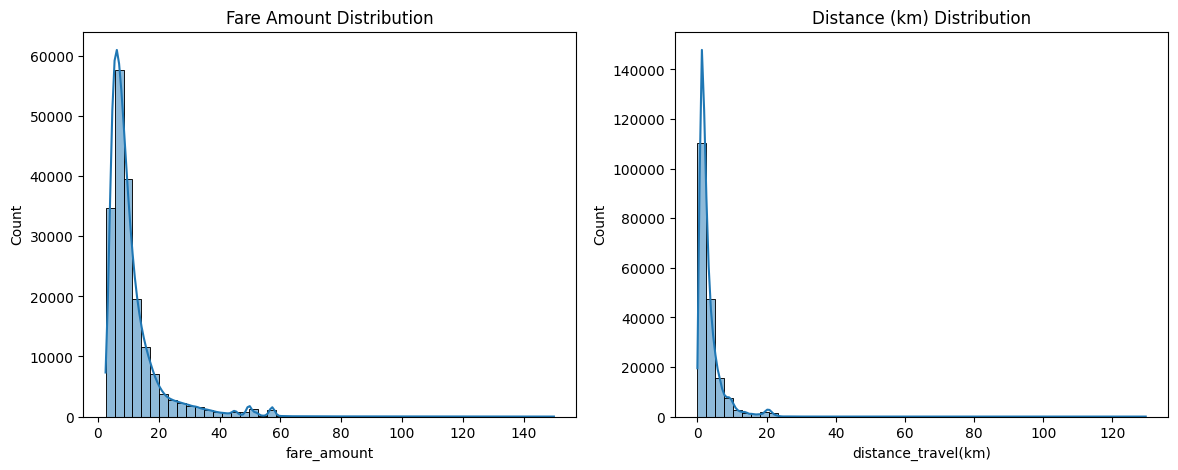

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
fig,axes = plt.subplots(1,2,figsize=(14,5))
sns.histplot(cleaned_df['fare_amount'],kde=True,ax=axes[0],bins=50)
axes[0].set_title('Fare Amount Distribution')

sns.histplot(cleaned_df['distance_travel(km)'], kde=True, ax=axes[1], bins=50)
axes[1].set_title('Distance (km) Distribution')

plt.show()

In [69]:
cleaned_df.isnull().sum()

,0
fare_amount,0
passenger_count,0
hour,0
day,0
weekend,0
month,0
year,0
distance_travel(km),0


# **applying log transformation on distance and fare column**

In [71]:
cleaned_df['fare_log'] = np.log1p(cleaned_df['fare_amount'])
cleaned_df['distance_km_log'] = np.log1p(cleaned_df['distance_travel(km)'])

/tmp/ipykernel_2108/3865421675.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['fare_log'] = np.log1p(cleaned_df['fare_amount'])
/tmp/ipykernel_2108/3865421675.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['distance_km_log'] = np.log1p(cleaned_df['distance_travel(km)'])


# **after log tranformation**

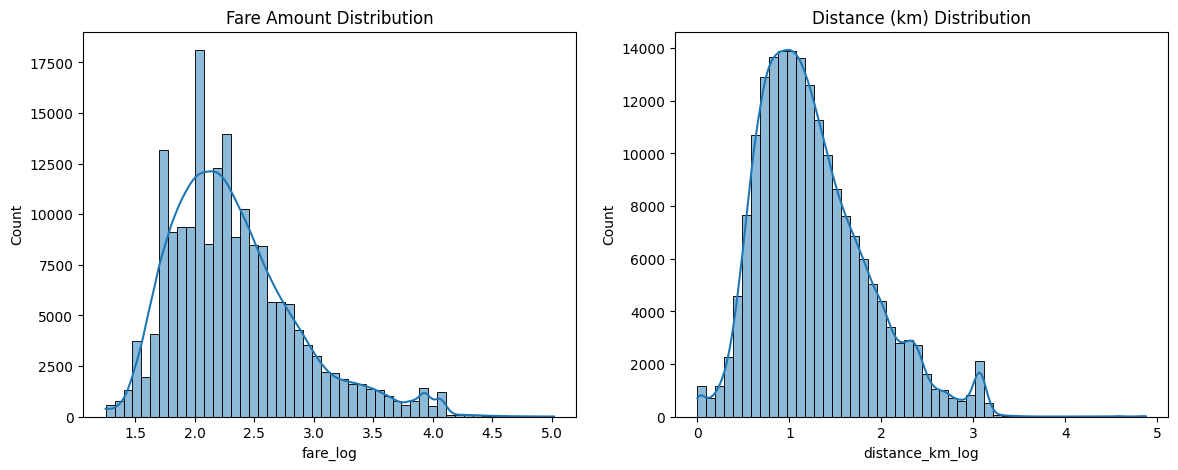

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
fig,axes = plt.subplots(1,2,figsize=(14,5))
sns.histplot(cleaned_df['fare_log'],kde=True,ax=axes[0],bins=50)
axes[0].set_title('Fare Amount Distribution')

sns.histplot(cleaned_df['distance_km_log'], kde=True, ax=axes[1], bins=50)
axes[1].set_title('Distance (km) Distribution')

plt.show()

In [73]:
cleaned_df

,fare_amount,passenger_count,hour,day,weekend,month,year,distance_travel(km),fare_log,distance_km_log
0,7.5,1,19,7,3,5,2015,1.683323,2.140066,0.987056
1,7.7,1,20,17,4,7,2009,2.457590,2.163323,1.240572
2,12.9,1,21,24,0,8,2009,5.036377,2.631889,1.797804
3,5.3,3,8,26,4,6,2009,1.661683,1.840550,0.978959
4,16.0,5,17,28,3,8,2014,4.475450,2.833213,1.700274
...,...,...,...,...,...,...,...,...,...,...
199995,3.0,1,10,28,6,10,2012,0.112210,1.386294,0.106349
199996,7.5,1,1,14,4,3,2014,1.875050,2.140066,1.056070
199997,30.9,2,0,29,0,6,2009,12.850319,3.462606,2.628308
199998,14.5,1,14,20,2,5,2015,3.539715,2.740840,1.512864


# **drop fare and distance column**

In [74]:
x = cleaned_df.drop(columns=['fare_amount','fare_log','distance_travel(km)'],axis=1)
y = cleaned_df['fare_log']

# **train test split**

In [75]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# **scale**

In [76]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# **Ann building**

In [81]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
modell = Sequential()
modell.add(Dense(64,activation='relu',input_dim=x_train_scaled.shape[1]))
modell.add(Dense(32,activation='relu'))
modell.add(Dense(1))
modell.compile(optimizer='adam',loss='mse',metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **train ANN**

In [82]:
from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True)
history = modell.fit(x_train_scaled,y_train,batch_size=64,epochs=100,validation_split=0.2,callbacks=[early_stop])

Epoch 1/100
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 0.1341 - mae: 0.2321 - val_loss: 0.0635 - val_mae: 0.1720
Epoch 2/100
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 0.0624 - mae: 0.1693 - val_loss: 0.0587 - val_mae: 0.1662
Epoch 3/100
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0604 - mae: 0.1659 - val_loss: 0.0616 - val_mae: 0.1652
Epoch 4/100
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0596 - mae: 0.1647 - val_loss: 0.0590 - val_mae: 0.1688
Epoch 5/100
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0587 - mae: 0.1634 - val_loss: 0.0593 - val_mae: 0.1673
Epoch 6/100
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0580 - mae: 0.1625 - val_loss: 0.0568 - val_mae: 0.1641
Epoch 7/100
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0571 - mae: 0.1614 - val_loss: 0.0574 - val_mae: 0.1626
Epoch 8/100
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0561 - mae: 0.1605 - val_loss: 0.0556 - val_mae: 0.1594
Epoch 9/100
1891/1891 ━━━━━━━

# **graph between val loss and training loss**

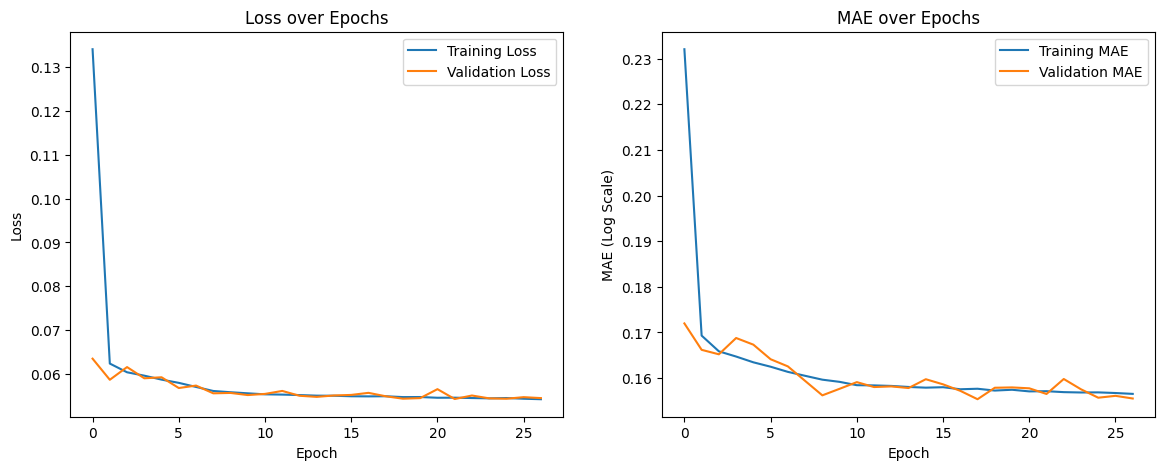

In [84]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
# MAE curve
axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('MAE over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (Log Scale)')
axes[1].legend()

# Display the complete figure
plt.show()

# **predicting and converting predict values into dollar by taking exp**

In [86]:
y_pred = modell.predict(x_test_scaled)

1182/1182 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [87]:
y_pred_dollars = np.expm1(y_pred)

In [88]:
y_test_dollars = np.exp(y_test)

# **evaluating model**

In [89]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_dollars, y_pred_dollars)
rmse = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
r2 = r2_score(y_test_dollars, y_pred_dollars)

print(f"Mean Absolute Error: ${mae:.2f}")
print(f"Root Mean Squared Error: ${rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

Mean Absolute Error: $2.19
Root Mean Squared Error: $4.47
R-squared Score: 0.7864


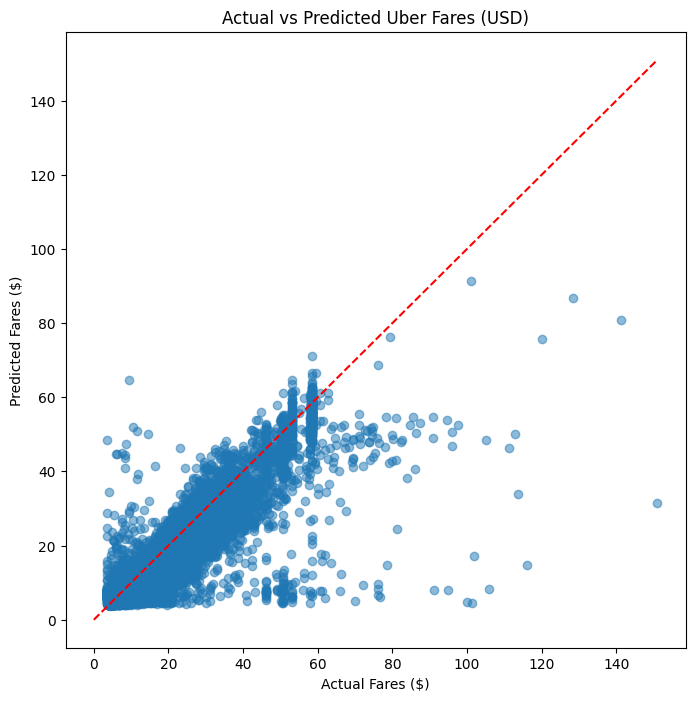

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(y_test_dollars, y_pred_dollars, alpha=0.5)

# Plot a perfect prediction diagonal line for reference
max_val = max(y_test_dollars.max(), y_pred_dollars.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')

plt.title('Actual vs Predicted Uber Fares (USD)')
plt.xlabel('Actual Fares ($)')
plt.ylabel('Predicted Fares ($)')
plt.show()